# Fault Subsections

This notebook demonstrates subsection-level view classes. Topics covered:

1. Creating a `FaultSubsection` facade
2. `FaultSubsectionData` — subsection attributes
3. `FaultSubsectionRuptures` — rupture participation and cumulative MFD
4. Direct instantiation of `FaultSubsectionData` and `FaultSubsectionRuptures`

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from parserf import (
    FaultModel,
    FaultModelDataset,
    FaultSubsection,
    FaultSubsectionData,
    FaultSubsectionRuptures,
    get_nearest_subsection_index,
)

In [2]:
# Coordinate in southern California (nearest parent fault: Compton)
ds = FaultModelDataset(FaultModel.NSHMP_2023)
idx = get_nearest_subsection_index(ds, lat=33.85, lon=-118.40)
print("Nearest subsection index:", idx)

Nearest subsection index: 811


## 1. FaultSubsection Facade

`FaultSubsection` validates the index and exposes `.data` and `.ruptures`.

In [3]:
sub = FaultSubsection(ds, index=idx)
print(sub)

FaultSubsection(fault_model=NSHMP_2023, index=811, name='Compton (2)')


## 2. FaultSubsectionData

Properties for a single subsection's attributes.

In [4]:
print("Index:       ", sub.data.index)
print("Name:        ", sub.data.name)
print("Parent ID:   ", sub.data.parent_id)
print("Parent Name: ", sub.data.parent_name)

Index:        811
Name:         Compton (2)
Parent ID:    43
Parent Name:  Compton


In [5]:
print("Geometry:    ", sub.data.geometry)
print("Length (km): ", round(sub.data.length_km, 3))
print("Width (km):  ", round(sub.data.width_km, 3))
print("Area (km\u00b2):  ", round(sub.data.area_km2, 3))

Geometry:     LINESTRING (-118.30314 33.79592, -118.31471 33.8006, -118.35945 33.8183, -118.43104 33.84393)
Length (km):  12.986
Width (km):   30.408
Area (km²):   394.862


In [6]:
print("Upper depth (km):  ", sub.data.upper_depth_km)
print("Lower depth (km):  ", sub.data.lower_depth_km)
print("Dip (degrees):     ", sub.data.dip)
print("Dip direction:     ", sub.data.dip_direction)
print("Aseismicity:       ", sub.data.aseismicity)

Upper depth (km):   5.2
Lower depth (km):   15.6
Dip (degrees):      20.0
Dip direction:      34.0
Aseismicity:        0.1


### geometry_3d (dipping surface, map view)

`geometry_3d` is the dipping fault surface as a Shapely `PolygonZ` in `(lon, lat, depth_km)`,
built by hanging the top trace (surface projection or surface trace) down-dip to the lower seismogenic depth. 

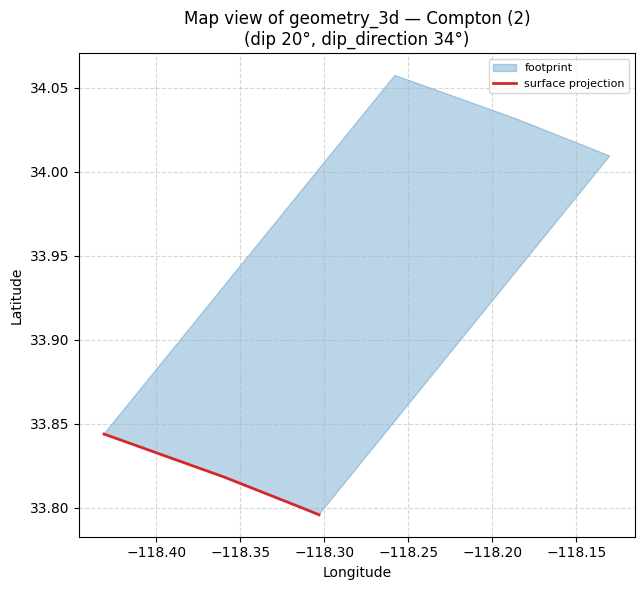

In [7]:
# Get the footprint with Shapely's `.exterior.xy`
footprint = sub.data.geometry_3d
fx, fy = footprint.exterior.xy
tx, ty = sub.data.geometry.xy

fig, ax = plt.subplots(figsize=(7, 6))
ax.fill(fx, fy, alpha=0.3, color="tab:blue", label="footprint")
ax.plot(tx, ty, color="tab:red", linewidth=2, label="surface projection")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    f"Map view of geometry_3d — {sub.data.name}\n"
    f"(dip {sub.data.dip:.0f}°, dip_direction {sub.data.dip_direction:.0f}°)"
)
ax.legend(fontsize=8)
ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 3. FaultSubsectionRuptures

Rupture participation data for a single subsection.

### participating_ruptures

GeoDataFrame of all rupture scenarios involving this subsection, enriched with merged geometry and
total length/area. There is one row per rupture.

**What is the `contributions` column?** A rupture can span subsections from several *parent faults*,
so each rupture row carries a `contributions` list of `(parent_id, area_pct)` tuples — each parent's
share, by area, of the rupture (percentages sum to 100). That lets you attribute a rupture's `rate`
to individual faults via `rate * area_pct / 100`. **Explode** the column to get one row per
(rupture, parent).

In [8]:
rups = sub.ruptures.participating_ruptures
print(f"{len(rups)} ruptures")
print("Columns:", list(rups.columns))
rups.head()

5190 ruptures
Columns: ['m', 'rate', 'depth', 'dip', 'width', 'rake', 'geometry', 'length_km', 'area_km2', 'contributions']


,m,rate,depth,dip,width,rake,geometry,length_km,area_km2,contributions
1975,7.66,4.321805e-15,4.682,34.3,23.885,71.0,"MULTILINESTRING ((-118.552 34.0202, -118.64926...",127.177358,3176.545047,"[(3, 14.924796731279569), (43, 62.107225134700..."
2039,7.33,2.931294e-09,4.900,27.1,25.184,61.0,"MULTILINESTRING ((-118.552 34.0202, -118.64926...",60.547321,1657.534124,"[(3, 28.6023005259089), (43, 71.3976994740911)]"
2040,7.43,1.801956e-09,5.158,25.8,25.604,62.0,"MULTILINESTRING ((-118.552 34.0202, -118.64926...",73.530383,2052.317420,"[(3, 23.100368715752083), (43, 76.899631284247..."
2041,7.52,1.494799e-09,5.332,24.8,25.888,63.0,"MULTILINESTRING ((-118.552 34.0202, -118.64926...",86.508714,2446.956875,"[(3, 19.374795532753385), (43, 80.625204467246..."
2042,7.55,1.325219e-09,5.310,26.9,25.168,65.0,"MULTILINESTRING ((-118.552 34.0202, -118.64926...",96.988993,2562.232141,"[(3, 18.50312014207105), (5, 4.499017237156169..."


In [9]:
# Examine the parent fault contribution for one rupture via its `contributions` list.
last_rup_idx = rups.index[-1]
row = rups.loc[last_rup_idx]
print("Length (km):            ", round(row["length_km"], 2))
print("Area (km²):             ", round(row["area_km2"], 2))
print("Geometry type:          ", row["geometry"].geom_type)
print("Parent area breakdown:")
for pid, area_pct in row["contributions"]:
    pname = ds.subsections.loc[ds.subsections["parent_id"] == pid, "parent_name"].iloc[0]
    print(f"  {pname} (id={pid}): {area_pct:.1f}%")

Length (km):             127.77
Area (km²):              3500.29
Geometry type:           MultiLineString
Parent area breakdown:
  Compton (id=43): 56.4%
  Yorba Linda (id=303): 6.7%
  Santa Monica (id=262): 7.7%
  Santa Monica Bay (id=261): 22.2%
  Peralta Hills (id=206): 7.1%


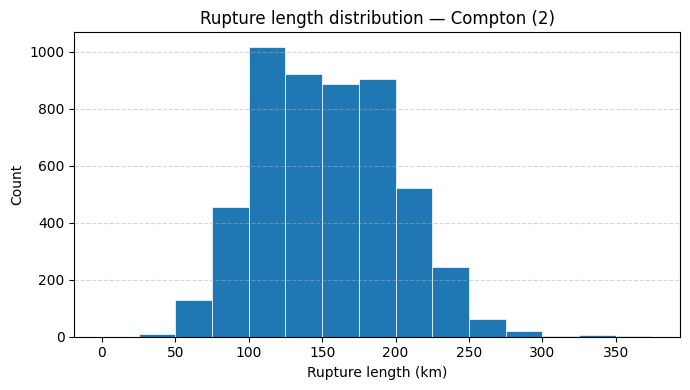

In [10]:
# Distribution of rupture lengths for this subsection
bin_width = 25
lengths = rups["length_km"]
bins = np.arange(0, lengths.max() + bin_width, bin_width)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lengths, bins=bins, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Rupture length (km)")
ax.set_ylabel("Count")
ax.set_title(f"Rupture length distribution — {sub.data.name}")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### cumulative_mfd

Cumulative magnitude frequency distribution (exceedance rates).

In [11]:
mfd = sub.ruptures.cumulative_mfd
mfd

,magnitude,cumulative_rate
0,6.98,4.766730e-04
1,7.10,4.656969e-04
2,7.16,4.655489e-04
3,7.19,4.423972e-04
4,7.20,4.423908e-04
...,...,...
83,7.99,5.733441e-07
84,8.00,5.733367e-07
85,8.01,7.313346e-11
86,8.02,7.035943e-11


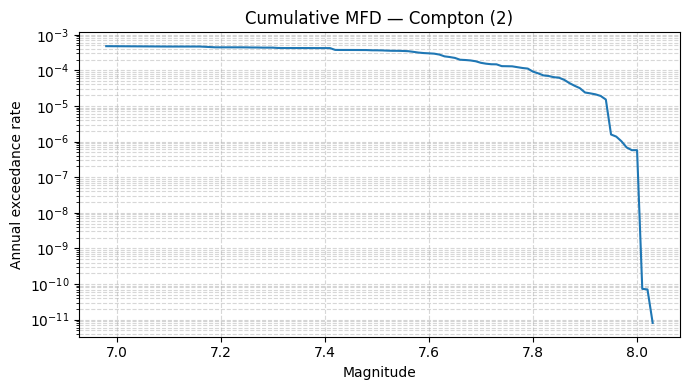

In [12]:
# Cumulative MFD for this subsection
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(mfd["magnitude"], mfd["cumulative_rate"], linewidth=1.5)
ax.set_xlabel("Magnitude")
ax.set_ylabel("Annual exceedance rate")
ax.set_title(f"Cumulative MFD \u2014 {sub.data.name}")
ax.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Direct Instantiation

`FaultSubsectionData` and `FaultSubsectionRuptures` can be used standalone
without going through the `FaultSubsection` facade.

In [13]:
data = FaultSubsectionData(ds, index=idx)
print("Name:", data.name)
print("Length (km):", round(data.length_km, 3))

Name: Compton (2)
Length (km): 12.986


In [14]:
ruptures = FaultSubsectionRuptures(ds, index=idx)
print("Participating ruptures:", len(ruptures.participating_ruptures))

Participating ruptures: 5190
